# nb2 — Two-Level Hierarchy PartitionExplainer (Owen Values)

### Core idea

Uses `shap.PartitionExplainer` with a custom two-level linkage tree:
- **ROOT → BACTERIA** & **PHAGE** → Each into 3 own models blocks

```text
                 ROOT
                /    \
        BACTERIA      PHAGE
        /  |  \      /  |  \
      NT2 Mega DB2  NT2 Mega DB2
```

- Explainer works directly in the full **18 824-dim** embedding space, with SHAP values are summed per model block: `block_contrib[name] = exp.values[0, start:end].sum()`. Thus owen values computed at the 6-leaf level give per-model attributions.

**Design rationale:**

Comparing a phage model directly against a bacteria model might be not informative: they encode different organisms and their embedding distributions are not necessary comparable. The scientifically meaningful comparisons are:

- **Within bacteria**: which of the 3 bacteria models (NT2, MegaDNA, DNABERT2) drives the prediction?
- **Within phage**: same question for the 3 phage models.
- **Bacteria group vs Phage group**: does the bacterium's sequence or the phage's sequence dominate the prediction overall?

This is exactly what a **two-level hierarchy** captures: the tree has two mid-nodes (bacteria, phage), each with 3 leaf blocks.

**Best practices applied:**
- Intra-group merges at distance 0.1 (leaves tightly coupled)
- Bacteria root vs Phage root merged at distance 1.0 (one step above)
- This two-level structure is the minimal hierarchy that separates within-group and between-group attribution

### Implementation
In NB2, the baseline is no longer a single fixed vector representing “all blocks absent,” as in NB1. Instead, the explainer uses a background matrix for the Partition masker, controlled by the BASELINEMODE parameter.

NB2 supports several background types:  
- `mean` — one row built from the column-wise mean of unique bacteria and unique phage embeddings.
- `median` — one row built from the column-wise median of unique bacteria and unique phage embeddings.
- `randomsample` — multiple real rows sampled from X_explain, balanced across positive and negative classes; in the final implementation, this is the recommended practical background for comparison experiments
- `deduplicated` — one row per unique bacterium (with counter part) and one row per unique phage (with counterpart), then concatinated into single dataset and deduplicated afterwards.
- `pair N` — proposed extension matching NB1 logic, where the background is built from a specific pair id in the dataset and used as a concrete biological reference.

NB2 supports both local and global explanations, but unlike NB1 it does not use frozen-side 3-dimensional variants. All explanations are performed in the full flat input space and then aggregated back to the six model blocks, plus the two organism groups.

- **Local explanation:** PartitionExplainer is run for one specific phage–bacterium pair from TARGETPAIRS. The returned per-dimension values are summed over each model block to obtain six block-level contributions, and then summed again by organism to obtain totalbacteria and totalphage.
- **Global explanation:** — explanations are computed over multiple dataset pairs and aggregated with the mean absolute SHAP value per block. The number of evaluated rows is controlled by `N_PAIRS_GLOBAL`, which can be either an integer (amount of randomly sampled pairs from the dataset) or all for the complete dataset.

---
## Section 0 - Setup


The original location of this notebook is a subfolder of the project. However, for proper functioning it needs to be started from the **project root** so it can access all dependencies and imports. Therefore, the next cell (the very first section of the notebook containing `%cd ..`) may need to be run multiple times until you see the desired folder as output: `Current Working Directory: /data/your.user/pbi`.

*You might not need to run the first cell if this notebook is already in the project root folder.*

In [3]:
import os
import sys

# 1. Change the working directory to the project root
%cd ..

# 2. Add the root directory to the Python path so imports work
sys.path.append(os.getcwd())

# 3. Verify we are in the right place
print(f"Current Working Directory: {os.getcwd()}")
# !ls # Optional: list files to confirm you see 'main.py' and 'pbi_utils'

/data/pavel.degterev/pbi
Current Working Directory: /data/pavel.degterev/pbi


/home/pavel.degterev/miniforge3/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
import shap
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch.nn.functional as F
from tqdm.auto import tqdm
from scipy.stats import spearmanr

from pbi_utils.logging import Logging, INFO, DEBUG
from pbi_utils.data_manager import H5pyEmbeddingsManager
from pbi_utils.config_parser_XAI import parse_config
#from main import parse_config

___
## Section 1 — Configuration

Under normal use, experiments can be reconfigured by modifying only this cell, while the rest of the notebook remains unchanged. It contains main user-editable parameters for Nb1, unless the model configuration is changed, in which case Section 2 needs to be changed accordingly. 

In [5]:
# ── USER CONFIGURATION ─────────────────────────────────────────────────────

# CONFIG_PATH = "model_configs/best_model_XAI.yaml"
CONFIG_PATH = 'XAI/bundle/best_model_XAI.yaml' 
# 'mean' | 'median' | 'deduplicated' | 'random_sample' | "pair N" - for example example "pair 1127"
BASELINE_MODE  = 'random_sample'  

# 'deduplicated' = X_dedup: deduplicated unique organisms (most theoretically sound
#               for PartitionExplainer — avoids pair-frequency bias)

RANDOM_SEED    = 48
N_RANDOM_BG    = 500     # samples if BASELINE_MODE == 'random_sample'
N_PAIRS_GLOBAL = 'all'    # "all" | int - how many rows used for global mean|SHAP| analysis
MAX_EVALS      = 500     # PartitionExplainer max_evals per explanation

FILTERED_PAIRS = [
    {'id': 788,  'bacterium_id': 153,  'phage_id': 2014},
    {'id': 939,  'bacterium_id': 153,  'phage_id': 2153},
    {'id': 2271, 'bacterium_id': 1869, 'phage_id': 6187},
    {'id': 741,  'bacterium_id': 5859, 'phage_id': 451},
    {'id': 728,  'bacterium_id': 5859, 'phage_id': 5924},
    {'id': 768,  'bacterium_id': 5859, 'phage_id': 5928},
]
TARGET_PAIRS = FILTERED_PAIRS[:2]  # set to a subset to run fewer
# ───────────────────────────────────────────────────────────────────────────
print(f"Baseline mode: {BASELINE_MODE}")
print(f"Target pairs ({len(TARGET_PAIRS)}): {[p['id'] for p in TARGET_PAIRS]}")

Baseline mode: random_sample
Target pairs (2): [788, 939]


In [6]:
tqdm.pandas()  # Initialize tqdm with pandas
Logging.set_logging_level(DEBUG)
# logger = Logging()

config = parse_config(CONFIG_PATH)
DEVICE = config.device
print(f"Device: {DEVICE}")

[INFO] Configuration loaded from XAI/bundle/best_model_XAI.yaml: Config(input_perphect=bacteria_df='data/perphect-data/public_data_set/bacteria_df.csv' phages_df='data/perphect-data/public_data_set/phages_df.csv' couples_df='data/perphect-data/public_data_set/couples_df.csv', embeddings_dir=data/embeddings_XAI, num_gpu=1, gpu_id=3, training_config=TrainingConfig(do_train=True epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 k_folds_cv=10 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='PCA' n_components_bacteria=500 n_components_phages=500), phages_embedding_models=[], compute_phages_embeddings=[], bacteria_embedding_models=[], compute_bacteria_embeddings=[], torch_num_threads=-1, output_dir=output/best_model_XAI/, classifier=BasicMLPClassifier({'mlp_params': [256, 128], 'dropout': 0.4}))
Device: cuda:3


In [7]:
# I guess that here should be custom embeddings folder to not mess up OG embeddings
CUSTOM_EMBEDDINGS_FOLDER = "XAI/embeddings"
output_manager = H5pyEmbeddingsManager(CUSTOM_EMBEDDINGS_FOLDER)
#output_manager = H5pyEmbeddingsManager(config.embeddings_dir)

[INFO] Embeddings will be stored or read from XAI/embeddings


___
## Section 2 — Block Definitions

Raw embedding layout:
- **Bacteria** (4036-dim): NT2 `[0:1536]`, MegaDNA `[1536:2500]`, DNABERT2 `[2500:4036]`
- **Phage** (14788-dim): NT2 `[0:1536]`, MegaDNA `[1536:2500]`, DNABERT2 `[2500:14788]`

In the concatenated 18824-dim vector phage indices are offset by 4036.

In [8]:
# ── Local block boundaries within each organism embedding ────────────────
BACT_BLOCKS = {
    'bact_NT2':      (0,    1536),
    'bact_MegaDNA':  (1536, 2500),
    'bact_DNABERT2': (2500, 4036),
}
BACT_DIM = 4036

PHAG_BLOCKS = {
    'phag_NT2':      (0,    1536),
    'phag_MegaDNA':  (1536, 2500),
    'phag_DNABERT2': (2500, 14788),
}
PHAG_DIM = 14788
TOTAL_DIM = BACT_DIM + PHAG_DIM  # 18824

# ── Combined block boundaries in the flat 18824-dim space ────────────────
BLOCKS = {
    **BACT_BLOCKS,
    **{k: (s + BACT_DIM, e + BACT_DIM) for k, (s, e) in PHAG_BLOCKS.items()},
}

BLOCK_NAMES = list(BLOCKS.keys())

# ── Organism-level grouping ───────────────────────────────────────────────
ORGANISM_GROUPS = {
    'bacteria': ['bact_NT2', 'bact_MegaDNA', 'bact_DNABERT2'],
    'phage':    ['phag_NT2', 'phag_MegaDNA', 'phag_DNABERT2'],
}

print(f'Block definitions (flat {TOTAL_DIM}-dim space):')
for name, (s, e) in BLOCKS.items():
    print(f'  {name}: [{s}:{e}]  ({e - s} dims)')
print(f'Total: {sum(e - s for s, e in BLOCKS.values())} dims')

Block definitions (flat 18824-dim space):
  bact_NT2: [0:1536]  (1536 dims)
  bact_MegaDNA: [1536:2500]  (964 dims)
  bact_DNABERT2: [2500:4036]  (1536 dims)
  phag_NT2: [4036:5572]  (1536 dims)
  phag_MegaDNA: [5572:6536]  (964 dims)
  phag_DNABERT2: [6536:18824]  (12288 dims)
Total: 18824 dims


___
## Section 3 — Data & Model Loading

Data loading is expected in the `.pt` format and file location based on a modified version of the `config` class.

Under the `def __init__(self, yaml_config: YAMLConfig, raw_dict):`  
```python
# new instances
self.model_path = os.path.join(self.output_dir, "trained_model.pth")
self.bacteria_pca_path = os.path.join(self.output_dir, "pca_bacteria.pkl")
self.phage_pca_path = os.path.join(self.output_dir, "pca_phage.pkl")
self.test_path = os.path.join(self.output_dir, "test_dataset.pt")
```

Those were also integrated into the main script for automatic saving of:
- PCA components upon creation, via `pickle.dump(pca_bact, open(config.bacteria_pca_path, 'wb'))`
- The test dataset upon splitting, via `torch.save(test, config.test_path)`
- *The model name was also hardcoded in the main script for simplicity*

It may be useful to add a manual path option to the notebook’s configuration section and make it compatible with standard CSV files as well.

---

## Important standalone configuration note

The final modifications made before forking were aimed at enabling standalone execution and reducing dependencies on the original project structure. As a result, `config_parser_XAI` is currently configured to load all required resources directly from the XAI package directory.

The path definitions introduced above were therefore modified to point to bundled resources. For example:

```python
self.model_path = os.path.join("XAI/bundle/trained_model.pth")
```

and similarly for the PCA components and test dataset.

The standalone configuration is currently implemented in config_parser_XAI, allowing the XAI module to operate independently of the main project structure. When running the training `main.py` pipeline or new tests on new models, the original config_parser should be updated to include the changes described earlier in this section. These modifications can be copied directly from the corresponding implementation in config_parser_XAI, which serves as the standalone-compatible reference version.

In [9]:
# ── Load embedding test dataset ────────────────────────────────────────────
emb_test_data = torch.load(config.test_path, map_location=DEVICE)
emb_test_data = emb_test_data.reset_index(drop=True)
# emb_test_data.head()

print('=== test initially designed to verify if right (filtered) df is used ===')
# Might be inappropriate for future cases 
print(f"emb_test_data: {len(emb_test_data)} rows, expected value 1426 after cleaning")
print(f"emb_test_data: {len(emb_test_data['phage_embedding'].iloc[0])} embedding lenght for bacteria, expected value 14788 before pca")
# This one is universally relevant
print(f"\nDistribution for {emb_test_data['interaction_type'].value_counts()}")

=== test initially designed to verify if right (filtered) df is used ===
emb_test_data: 1426 rows, expected value 1426 after cleaning
emb_test_data: 14788 embedding lenght for bacteria, expected value 14788 before pca

Distribution for interaction_type
0    1051
1     375
Name: count, dtype: int64


In [13]:
# ── Load PCA objects ───────────────────────────────────────────────────────
with open(config.bacteria_pca_path, 'rb') as f:
    pca_bact = pickle.load(f)

with open(config.phage_pca_path, 'rb') as f:
    pca_phag = pickle.load(f)

print(f"pca_bact: {pca_bact.n_components_} components, input dim {pca_bact.n_features_in_}")
print(f"pca_phag: {pca_phag.n_components_} components, input dim {pca_phag.n_features_in_}")

pca_bact: 500 components, input dim 4036
pca_phag: 500 components, input dim 14788


In [14]:
# ── Load MLP model ─────────────────────────────────────────────────────────
bacterium_embed_size = 500 #len(emb_test_data["bacterium_embedding"].iloc[0])
phage_embed_size = 500 #len(emb_test_data["phage_embedding"].iloc[0])
model = config.classifier(bacterium_embed_size, phage_embed_size, **config.classifier_params)

model.load_state_dict(torch.load(config.model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print(f"Model loaded → {DEVICE}, eval mode.")
print(model)
print()

Model loaded → cuda:3, eval mode.
MLPClassifier(mlp_params: [256, 128], dropout=0.4)



In [15]:
# ── Model implementation  ───────────────────────────────────────────────────
def predict_fn(X: np.ndarray) -> np.ndarray:
    """
    X : (batch, 18824) float array
    Returns class-1 probabilities as (batch,) float array.
    """
    bact_raw  = X[:, :BACT_DIM]
    phage_raw = X[:, BACT_DIM:]
    bact_pca  = pca_bact.transform(bact_raw)
    phage_pca = pca_phag.transform(phage_raw)
    bact_t  = torch.from_numpy(bact_pca).float().to(DEVICE)
    phage_t = torch.from_numpy(phage_pca).float().to(DEVICE)
    with torch.no_grad():
        logits = model(bact_t, phage_t)
        probs  = torch.softmax(logits, dim=1)[:, 1]
    return probs.detach().cpu().numpy()

___
## Section 4 — Background & embedding matrix construction

In [16]:
def tensor_to_numpy(t):
    return t.detach().cpu().numpy()


def _to_np(col):
    return np.stack([t.detach().cpu().numpy() for t in col])


def build_background(emb_test_data, mode, seed=42, n=200, X_explain=None):
    """
    Build background matrix for PartitionExplainer masker.

    Parameters
    ----------
    emb_test_data : pd.DataFrame
        Must contain at least columns:
        - 'bacterium_id'
        - 'phage_id'
        - 'interaction_type' (0/1), for balanced random sampling.
    mode : {'mean', 'median', 'random_sample', 'deduplicated'}
    seed : int
        Random seed (used for 'random_sample').
    n : int
        Number of samples for 'random_sample'.
    X_explain : np.ndarray, shape (N, D)
        Full matrix, required for 'random_sample'.

    Returns
    -------
    np.ndarray of shape (k, D)
    """
    unique_bact = emb_test_data.drop_duplicates(subset="bacterium_id")
    unique_phag = emb_test_data.drop_duplicates(subset="phage_id")

    bact_stack = _to_np(unique_bact["bacterium_embedding"])
    phag_stack = _to_np(unique_phag["phage_embedding"])

    if mode == "mean":
        bvec = bact_stack.mean(0)
        pvec = phag_stack.mean(0)
        return np.concatenate([bvec, pvec]).reshape(1, -1)

    elif mode == "median":
        bvec = np.median(bact_stack, 0)
        pvec = np.median(phag_stack, 0)
        return np.concatenate([bvec, pvec]).reshape(1, -1)

    elif mode == "random_sample":
        # Balanced baseline: sample ~n/2 from each class (0 and 1)
        if X_explain is None:
            raise ValueError("X_explain required for mode='random_sample'")

        if "interaction_type" not in emb_test_data.columns:
            raise ValueError(
                "emb_test_data must have 'interaction_type' column "
                "for balanced random_sample baseline."
            )

        rng = np.random.default_rng(seed)

        # indices in emb_test_data for each class
        idx_all = np.arange(len(emb_test_data))
        y = emb_test_data["interaction_type"].to_numpy()

        idx_0 = idx_all[y == 0]
        idx_1 = idx_all[y == 1]

        if len(idx_0) == 0 or len(idx_1) == 0:
            # Fall back to unbalanced random sampling if one class is missing
            idx = rng.choice(len(X_explain), size=min(n, len(X_explain)), replace=False)
            return X_explain[idx]

        # Desired per-class sizes
        half = n // 2
        n0 = min(half, len(idx_0))
        n1 = min(n - n0, len(idx_1))  # keep total ≤ n

        sample_0 = rng.choice(idx_0, size=n0, replace=False)
        sample_1 = rng.choice(idx_1, size=n1, replace=False)

        explain_idx = np.concatenate([sample_0, sample_1])
        rng.shuffle(explain_idx)

        return X_explain[explain_idx]

    elif mode == "deduplicated":
        # One flat row per unique bacterium, one per unique phage, then deduplicate.
        # Avoids frequency bias: a bacterium in 100 pairs does not dominate the background.
        X_ub = np.stack([
            np.concatenate([
                row["bacterium_embedding"].detach().cpu().numpy(),
                row["phage_embedding"].detach().cpu().numpy(),
            ])
            for _, row in unique_bact.iterrows()
        ])
        X_up = np.stack([
            np.concatenate([
                row["bacterium_embedding"].detach().cpu().numpy(),
                row["phage_embedding"].detach().cpu().numpy(),
            ])
            for _, row in unique_phag.iterrows()
        ])
        return np.unique(np.concatenate([X_ub, X_up], axis=0), axis=0)
    
    elif mode.lower().startswith("pair"):
        parts = mode.split()
        if len(parts) != 2:
            raise ValueError(f"Invalid pair background format {mode!r}. Use format 'pair 1127'.")

        try:
            pairid = int(parts[1])
        except ValueError:
            raise ValueError(f"Invalid pair background format {mode!r}. Pair id must be an integer, e.g. 'pair 1127'.")

        rows = emb_test_data.loc[emb_test_data["id"] == pairid]
        if len(rows) == 0:
            raise ValueError(f"Pair background requested for id={pairid}, but this id was not found in embtestdata.")
        if len(rows) > 1:
            raise ValueError(f"Pair background requested for id={pairid}, but found {len(rows)} rows. Expected exactly 1 row.")

        row = rows.iloc[0]
        bvec = tensor_to_numpy(row["bacteriumembedding"])
        pvec = tensor_to_numpy(row["phageembedding"])
        return np.concatenate([bvec, pvec]).reshape(1, -1)

    else:
        raise ValueError(
            f"Unknown baseline mode: {mode!r}. "
            "Use 'mean', 'median', 'deduplicated' or 'random_sample'"
        )


print("build_background() & co - defined.")

build_background() & co - defined.


In [17]:
# Build full (N, 18824) matrix directly from embeddings
X_explain = np.stack([
    np.concatenate([
        tensor_to_numpy(row['bacterium_embedding']),
        tensor_to_numpy(row['phage_embedding']),
    ])
    for _, row in emb_test_data.iterrows()
])  # shape: (N, 18824)

print(f'X_explain shape: {X_explain.shape}')

# Sanity-check predict_fn
_preds = predict_fn(X_explain[:3])
print(f'Sanity-check predictions (first 3 rows): {_preds}')

background = build_background(
    emb_test_data,
    mode=BASELINE_MODE,
    seed=RANDOM_SEED,
    n=N_RANDOM_BG,
    X_explain=X_explain,
)
print(f'Background shape ({BASELINE_MODE!r}): {background.shape}')

X_explain shape: (1426, 18824)
Sanity-check predictions (first 3 rows): [9.9884367e-01 4.6469810e-13 4.3970289e-10]
Background shape ('random_sample'): (500, 18824)


___
## Section 5 — Two-Level Linkage Tree

Builds the scipy-format linkage matrix that encodes the three-level hierarchy:

```text
ROOT (dist=1.0)
 |
 ├─ BACTERIA (dist=0.5)
 │   ├─ bact_NT2      (dims 0–1535)
 │   ├─ bact_MegaDNA  (dims 1536–2499)
 │   └─ bact_DNABERT2 (dims 2500–4035)
 |
 └─ PHAGE    (dist=0.5)
     ├─ phag_NT2      (dims 4036–5571)
     ├─ phag_MegaDNA  (dims 5572–6535)
     └─ phag_DNABERT2 (dims 6536–18823)
```

In [18]:
def build_two_level_linkage(total_dim, blocks_dict):
    """
    Builds a scipy-format linkage matrix encoding a two-level hierarchy.

    Distance schedule:
      0.1  — merge individual dims within a block      (level 1: leaf chains)
      0.5  — merge 3 block-roots within an organism    (level 2: organism)
      1.0  — merge bacteria-root with phage-root       (level 3: ROOT)
    """
    next_id = total_dim
    sizes = {i: 1 for i in range(total_dim)}
    rows = []

    # ── Level 1: chain dims within each block ─────────────────────────
    block_roots = {}
    for block_name, (start, end) in blocks_dict.items():
        leaves = list(range(start, end))
        current, cur_size = leaves[0], 1
        for leaf in leaves[1:]:
            rows.append([current, leaf, 0.1, cur_size + 1])
            sizes[next_id] = cur_size + 1
            current = next_id
            cur_size += 1
            next_id += 1
        block_roots[block_name] = current

    # ── Level 2: merge 3 block-roots within each organism ─────────────
    organism_roots = {}
    for org_name, org_blocks in [
        ('bacteria', ['bact_NT2', 'bact_MegaDNA', 'bact_DNABERT2']),
        ('phage',    ['phag_NT2', 'phag_MegaDNA', 'phag_DNABERT2']),
    ]:
        roots = [block_roots[b] for b in org_blocks]
        current = roots[0]
        cur_size = sizes[current]
        for r in roots[1:]:
            merge_size = cur_size + sizes[r]
            rows.append([current, r, 0.5, merge_size])
            sizes[next_id] = merge_size
            current = next_id
            cur_size = merge_size
            next_id += 1
        organism_roots[org_name] = current

    # ── Level 3: merge bacteria-root with phage-root (ROOT) ───────────
    bact_root  = organism_roots['bacteria']
    phage_root = organism_roots['phage']
    total_size = sizes[bact_root] + sizes[phage_root]
    rows.append([bact_root, phage_root, 1.0, total_size])

    return np.asarray(rows, dtype=float)


linkage_matrix = build_two_level_linkage(TOTAL_DIM, BLOCKS)
print(f'Linkage matrix shape: {linkage_matrix.shape}')  # (TOTAL_DIM - 1, 4)

last = linkage_matrix[-1]
print(f'Root merge: node {int(last[0])} + node {int(last[1])} '
      f'at dist={last[2]:.1f}, total size={int(last[3])}')
assert int(last[3]) == TOTAL_DIM, 'Root size mismatch!'
print('Linkage matrix verified.')

Linkage matrix shape: (18823, 4)
Root merge: node 37643 + node 37645 at dist=1.0, total size=18824
Linkage matrix verified.


## Section 6 — PartitionExplainer

In [19]:
masker   = shap.maskers.Partition(background, clustering=linkage_matrix)
explainer = shap.Explainer(predict_fn, masker, algorithm='partition')
print('Two-level PartitionExplainer ready.')

Two-level PartitionExplainer ready.


## Section 7 — Local explanation
**Calculating Model importance for individual pairs**  
`run_kernel_shap_for_pairs()` - Main automation function: loops over pairs set in configuration, runs KernelExplainer, collects structured results.

In [20]:
def run_partition_shap_for_pairs(
    pair_list,
    explainer,
    emb_test_data,
    X_explain,
    BLOCKS,
    ORGANISM_GROUPS,
    predict_fn,
    MAX_EVALS,
    BASELINE_MODE,
    verbose=True,
):
    """
    Run PartitionExplainer for each pair in pair_list.

    Parameters
    ----------
    pair_list : list of dicts with keys 'id', 'bacterium_id', 'phage_id'
    explainer : shap.Explainer (PartitionExplainer with masker already set)
    emb_test_data : pd.DataFrame
    X_explain : np.ndarray
    BLOCKS : dict[str, tuple[int, int]]
    ORGANISM_GROUPS : dict[str, list[str]]
    predict_fn : callable
    MAX_EVALS : int
    BASELINE_MODE : str
    verbose : bool

    Returns
    -------
    result_df  : pd.DataFrame — one row per pair, columns = block contribs + meta
    json_results : list of dicts — structured JSON matching nb1 format (without cross diffs)
    """
    records      = []
    json_results = []
    pbar = None

    if not verbose:
        pbar = tqdm(total=len(pair_list), desc="Global SHAP", dynamic_ncols=True)

    for i, pair in enumerate(pair_list):
        if verbose:
            print(
                f'  [{i+1}/{len(pair_list)}] pair_id={pair["id"]} '
                f'bact={pair["bacterium_id"]} phage={pair["phage_id"]}',
                end=' ... '
            )



        rows = emb_test_data.loc[emb_test_data['id'] == pair['id']]
        if len(rows) == 0:
            if verbose:
                print(f'WARNING: pair_id {pair["id"]} not found in emb_test_data — skipping.')
            else: 
                pbar.update(1)
            continue

        row = rows.iloc[0]
        idx = emb_test_data.index.get_loc(row.name)
        x   = X_explain[idx:idx + 1]

        exp = explainer(x, max_evals=MAX_EVALS, silent=not verbose)

        # Block-level contributions
        block_contribs = {
            name: float(exp.values[0, s:e].sum())
            for name, (s, e) in BLOCKS.items()
        }

        # Organism-level aggregation
        org_contribs = {
            org: sum(block_contribs[b] for b in org_blocks)
            for org, org_blocks in ORGANISM_GROUPS.items()
        }

        base_val  = float(np.ravel(exp.base_values)[0])
        pred_prob = float(predict_fn(x)[0])
        shap_sum  = sum(block_contribs.values())

        if verbose:
            print(f'pred={pred_prob:.4f}  base={base_val:.4f}  shap_sum={shap_sum:+.4f}')
        else:
            pbar.set_postfix_str(f"{i+1}/{len(pair_list)}")

        record = {
            'pair_id':      pair['id'],
            'bacterium_id': pair['bacterium_id'],
            'phage_id':     pair['phage_id'],
            'true_label':   int(row['interaction_type']),
            'pred_prob':    pred_prob,
            **block_contribs,
            **{f'total_{o}': v for o, v in org_contribs.items()},
        }
        records.append(record)

        json_results.append({
            'pair_id':        pair['id'],
            'bacterium_id':   pair['bacterium_id'],
            'phage_id':       pair['phage_id'],
            'baseline_mode':  BASELINE_MODE,
            'true_label':     int(row['interaction_type']),
            'pred_prob':      pred_prob,
            'expected_value': base_val,
            'shap_sum':       shap_sum,
            'shap_values':    block_contribs,
            'organism_totals': org_contribs,
        })
        
        if pbar is not None:
            pbar.update(1)

    if pbar is not None:
        pbar.close()

    return pd.DataFrame(records), json_results


print('run_partition_shap_for_pairs() defined.')

run_partition_shap_for_pairs() defined.


In [21]:
# Run for TARGET_PAIRS
df_target, json_results = run_partition_shap_for_pairs(
    pair_list       = TARGET_PAIRS,
    explainer       = explainer,
    emb_test_data   = emb_test_data,
    X_explain       = X_explain,
    BLOCKS          = BLOCKS,
    ORGANISM_GROUPS = ORGANISM_GROUPS,
    predict_fn      = predict_fn,
    MAX_EVALS       = MAX_EVALS,
    BASELINE_MODE   = BASELINE_MODE,
    verbose         = True,
)

print(f"\nResults for {len(df_target)} target pairs:")
display(df_target)

  [1/2] pair_id=788 bact=153 phage=2014 ... 

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:12, 12.46s/it]               


pred=0.9997  base=0.4029  shap_sum=+0.5968
  [2/2] pair_id=939 bact=153 phage=2153 ... 

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:11, 11.20s/it]               

pred=0.9998  base=0.4029  shap_sum=+0.5969

Results for 2 target pairs:


,pair_id,bacterium_id,phage_id,true_label,pred_prob,bact_NT2,bact_MegaDNA,bact_DNABERT2,phag_NT2,phag_MegaDNA,phag_DNABERT2,total_bacteria,total_phage
0,788,153,2014,1,0.999701,0.209329,0.095895,-0.075378,0.135821,0.108939,0.122155,0.229846,0.366915
1,939,153,2153,1,0.999835,0.227815,0.067904,-0.076424,0.170904,0.115343,0.091354,0.219295,0.377601


## Section 10 — Global Multi-Pair Analysis

Run PartitionExplainer over `N_PAIRS_GLOBAL` rows from `X_explain` and
accumulate results into `result_df` and `mean_abs_shap`.

In [27]:
def run_global_mean_shap(
    emb_test_data,
    X_explain,
    explainer,
    BLOCKS,
    ORGANISM_GROUPS,
    predict_fn,
    MAX_EVALS,
    BASELINE_MODE,
    n_pairs,
    seed=42,
):
    """
    Sample n_pairs rows from emb_test_data and compute mean |SHAP| per block.

    Parameters
    ----------
    emb_test_data : pd.DataFrame
    X_explain : np.ndarray
    explainer : shap.Explainer
    BLOCKS : dict[str, tuple[int, int]]
    ORGANISM_GROUPS : dict[str, list[str]]
    predict_fn : callable
    MAX_EVALS : int
    BASELINE_MODE : str
    n_pairs : int | str
        Number of pairs to sample, or "all" to use the full dataset.
    seed : int

    Returns
    -------
    df_global : pd.DataFrame
        Per-pair SHAP values.
    mean_abs_shap : pd.Series
        Mean |SHAP| per block.
    """
    if isinstance(n_pairs, str):
        if n_pairs.lower() != "all":
            raise ValueError("n_pairs must be an int or the string 'all'.")
        if len(emb_test_data) != len(X_explain):
            raise ValueError(
                f"Length mismatch: len(emb_test_data)={len(emb_test_data)} "
                f"!= len(X_explain)={len(X_explain)}"
            )
        sampled_rows = emb_test_data.reset_index(drop=True)
    else:
        rng = np.random.default_rng(seed)
        n = min(n_pairs, len(emb_test_data))
        sampled_idx = rng.choice(len(emb_test_data), size=n, replace=False)
        sampled_rows = emb_test_data.iloc[sampled_idx].reset_index(drop=True)

    pair_list = [
        {
            "id": int(r["id"]),
            "bacterium_id": int(r["bacterium_id"]),
            "phage_id": int(r["phage_id"]),
        }
        for _, r in sampled_rows.iterrows()
    ]

    df_global, _ = run_partition_shap_for_pairs(
        pair_list=pair_list,
        explainer=explainer,
        emb_test_data=emb_test_data,
        X_explain=X_explain,
        BLOCKS=BLOCKS,
        ORGANISM_GROUPS=ORGANISM_GROUPS,
        predict_fn=predict_fn,
        MAX_EVALS=MAX_EVALS,
        BASELINE_MODE=BASELINE_MODE,
        verbose=False,
    )

    block_names = list(BLOCKS.keys())

    mean_abs_shap = (
        df_global[block_names]
        .abs()
        .mean()
    )

    return df_global, mean_abs_shap

In [29]:
print(f"Computing global {BASELINE_MODE} |SHAP| over {N_PAIRS_GLOBAL} pairs...")
df_global, mean_abs_shap = run_global_mean_shap(
    emb_test_data   = emb_test_data,
    X_explain       = X_explain,
    explainer       = explainer,
    BLOCKS          = BLOCKS,
    ORGANISM_GROUPS = ORGANISM_GROUPS,
    predict_fn      = predict_fn,
    MAX_EVALS       = MAX_EVALS,
    BASELINE_MODE   = BASELINE_MODE,
    n_pairs         = N_PAIRS_GLOBAL,
    seed            = RANDOM_SEED,
)

print(f"\nGlobal {BASELINE_MODE} |SHAP| per block:")
print(mean_abs_shap.to_string())

print('\n=== Mean organism attribution (bacteria vs phage) ===')
display(df_global[['total_bacteria', 'total_phage']].mean())

Computing global random_sample |SHAP| over all pairs...


Global SHAP:   0%|          | 0/1426 [00:00<?, ?it/s]


Global random_sample |SHAP| per block:
bact_NT2         0.155744
bact_MegaDNA     0.028187
bact_DNABERT2    0.035857
phag_NT2         0.140224
phag_MegaDNA     0.117035
phag_DNABERT2    0.022245

=== Mean organism attribution (bacteria vs phage) ===


total_bacteria   -0.050472
total_phage      -0.077337
dtype: float64

### Local data saving and retrieval section
It took 4h, so let's do it right here

In [30]:
os.makedirs("XAI/results/data", exist_ok=True)

# ── 1. Full global dump as its own file ─────────────────────────────────────
out_global_csv = f"XAI/results/data/nb2_{BASELINE_MODE}_global_on_{N_PAIRS_GLOBAL}_pairs.csv"
df_global.to_csv(out_global_csv, index=False)
print(f"Saved global dump CSV → {out_global_csv}")

Saved global dump CSV → XAI/results/data/nb2_random_sample_global_on_all_pairs.csv


In [6]:
import pandas as pd

out_global_csv = f"XAI/results/data/nb2_{BASELINE_MODE}_global_on_{N_PAIRS_GLOBAL}_pairs.csv"
df_global = pd.read_csv(out_global_csv)

___
## Visualisation

Note: Each of visualization algorithms will save all pictures in the `pojectRoot/XAI/results`  
Naming convention: PairID_Method_Description.png

In [7]:
# ── Colour palette ─────────────────────────────────────────────────────────
COLOR_POS  = "#d62728"   # red — positive SHAP (pushes toward interaction)
COLOR_NEG  = "#1f77b4"   # blue — negative SHAP (pushes away)
COLOR_GLOBAL = "#5fc25f"   # green — for global importance block

COLOR_PHAG = "#1f77b4"
COLOR_BACT = "#d62728" 

def signed_colors(values):
    """Return a list of colors based on the sign of each value."""
    return [COLOR_POS if v >= 0 else COLOR_NEG for v in values]

## Local explanations

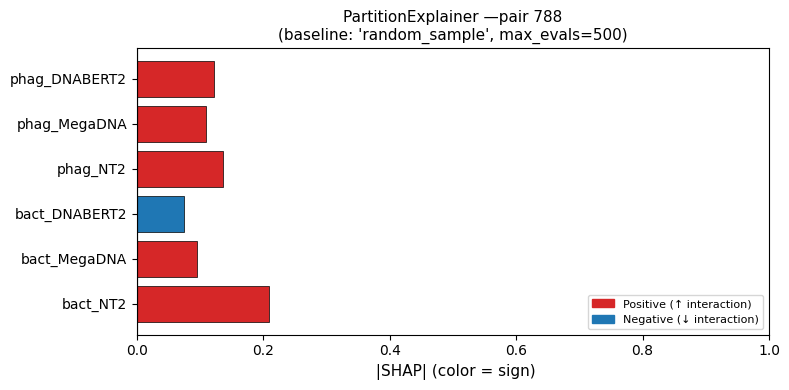

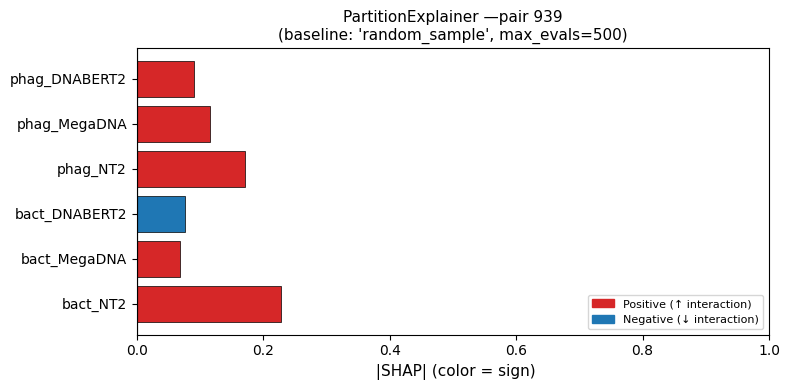

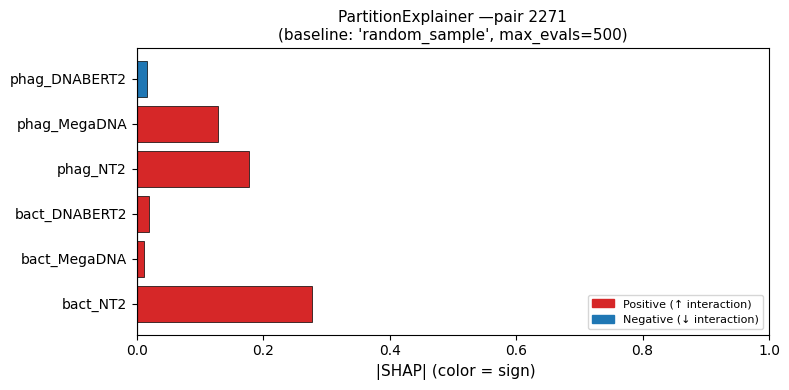

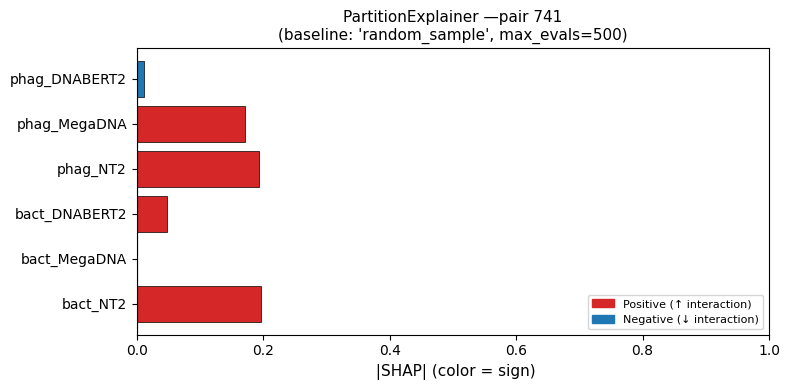

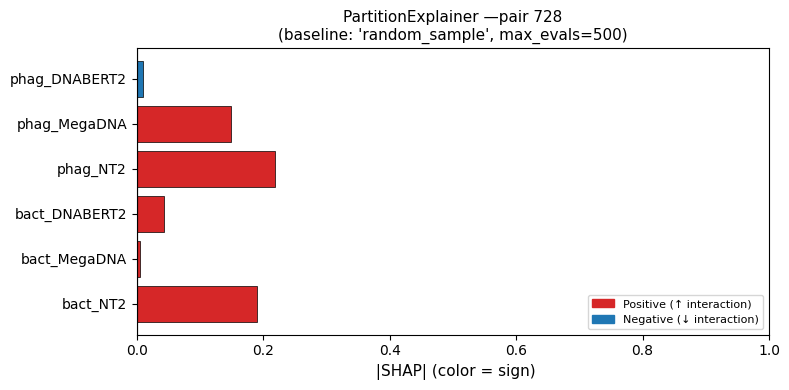

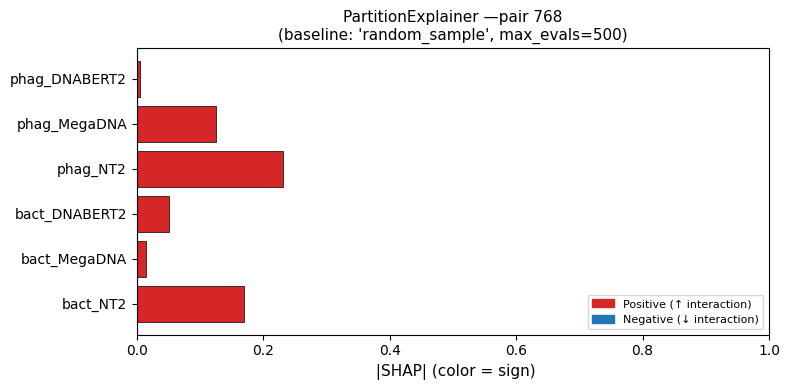

In [ ]:
# ── 11a. Per-pair signed SHAP bar chart ────────────────────────────────────
os.makedirs("XAI/results", exist_ok=True)

for _, row in df_target.iterrows():
    pair_id = int(row["pair_id"])
    vals    = [row[name] for name in BLOCK_NAMES]
    
    # Colors still depend on sign of the original values
    colors  = signed_colors(vals)   # unchanged
    
    pred    = row["pred_prob"]
    label   = "Interacting" if row["true_label"] == 1 else "Non-interacting"

    fig, ax = plt.subplots(figsize=(8, 4))
    
    # <- key change: use absolute values for bar lengths
    abs_vals = [abs(v) for v in vals]
    ax.barh(BLOCK_NAMES, abs_vals, color=colors, edgecolor="k", linewidth=0.5)
    
    ax.set_xlim(0, 1.0)

    # Optional: remove the zero line or move it to the left edge
    ax.axvline(0, color="k", linewidth=0.8)
    ax.set_xlabel("hierarchy SHAP (color = sign)", fontsize=11)
    ax.set_title(
        f'PartitionExplainer —pair {pair_id}\n'
        f'(baseline: {BASELINE_MODE!r}, max_evals={MAX_EVALS})',
        fontsize=11,
    )

    pos_patch = mpatches.Patch(color=COLOR_POS, label="Positive (↑ interaction)")
    neg_patch = mpatches.Patch(color=COLOR_NEG, label="Negative (↓ interaction)")
    ax.legend(handles=[pos_patch, neg_patch], fontsize=8, loc="lower right")

    plt.tight_layout()
    fig.savefig(f"XAI/results/{pair_id}_{BASELINE_MODE}_hierarchy_shap_pair.png", dpi=130)
    plt.show()
    plt.close(fig)

## Global explanations

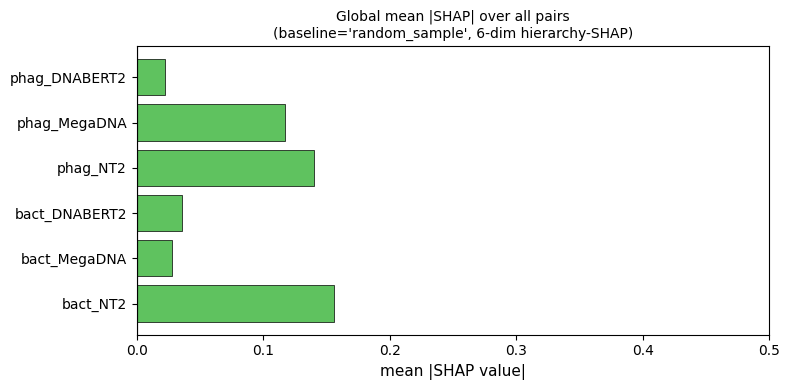

Saved global mean |SHAP| chart.


In [18]:
# ── 11b. Global mean |SHAP| bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

#mean_abs_shap_sorted = mean_abs_shap.sort_index()  # alphabetical by name

# ---------- quick fix ---------------
block_names = list(BLOCKS.keys())

mean_abs_shap = (
    df_global[block_names]
    .abs()
    .mean()
)
# ---------- quick fix ---------------

ax.barh(
    mean_abs_shap.index,
    mean_abs_shap.values,
    color=COLOR_GLOBAL,
    edgecolor="k",
    linewidth=0.5,
)

# Use the same x-axis scale as per-pair charts
ax.set_xlim(0, 0.5)

ax.set_xlabel("mean |SHAP value|", fontsize=11)
ax.set_title(
    f"Global mean |SHAP| over {N_PAIRS_GLOBAL} pairs\n"
    f"(baseline={BASELINE_MODE!r}, 6-dim hierarchy-SHAP)",
    fontsize=10,
)

# With all positive bars, a vertical line at 0 is optional, but harmless
ax.axvline(0, color="k", linewidth=0.8)

plt.tight_layout()
fig.savefig(f"XAI/results/global_hierarchy_{BASELINE_MODE}_shap.png", dpi=130)
plt.show()
plt.close(fig)

print("Saved global mean |SHAP| chart.")

## Confusion matrices:
Based on absolut mean (green) & mean (color coded) 

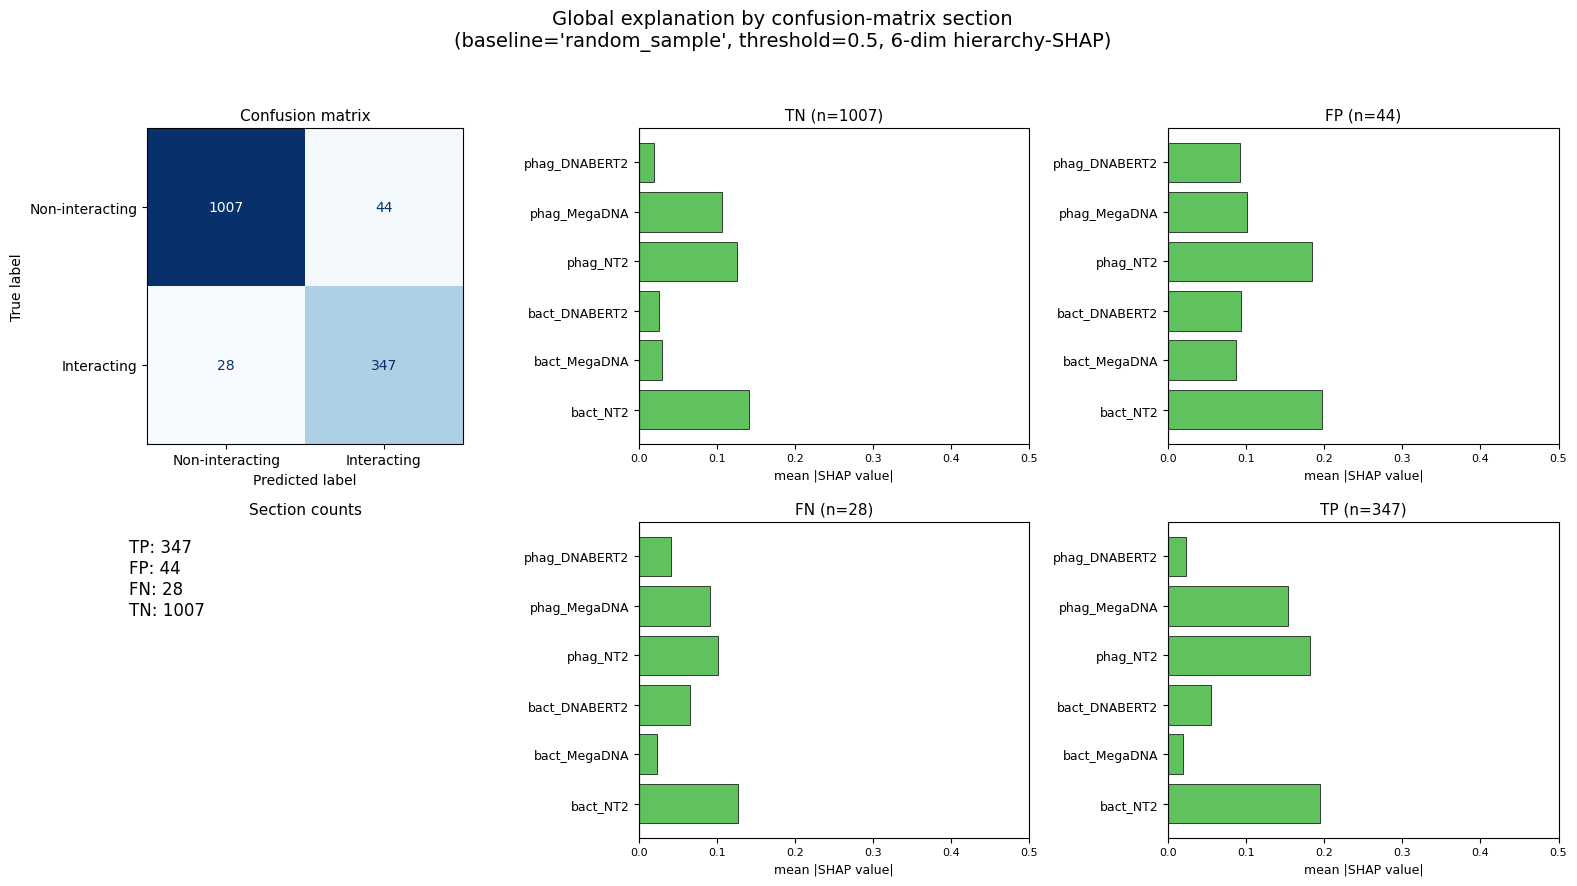

Saved combined confusion-matrix layout.


In [23]:
# ── 11c+. Confusion matrix + SHAP plots in one matrix-like layout ───────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("XAI/results", exist_ok=True)

CLASSIF_THRESHOLD = 0.5

# Start from the global per-pair dataframe produced in Section 8
df_cm = df_global.copy()

# Match NB1 naming if needed
# Expected in NB1 final: truelabel, predprob
df_cm["pred_label"] = (df_cm["pred_prob"] >= CLASSIF_THRESHOLD).astype(int)

def cm_section(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    elif y_true == 0 and y_pred == 0:
        return "TN"
    elif y_true == 0 and y_pred == 1:
        return "FP"
    elif y_true == 1 and y_pred == 0:
        return "FN"
    else:
        raise ValueError("Unexpected label combination.")

df_cm["cm_section"] = [
    cm_section(yt, yp) for yt, yp in zip(df_cm["true_label"], df_cm["pred_label"])
]

# Confusion matrix values
cm = confusion_matrix(
    df_cm["true_label"],
    df_cm["pred_label"],
    labels=[0, 1]
)

# ---- ONE FIGURE, MULTIPLE SUBPLOTS ----
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    f"Global explanation by confusion-matrix section\n"
    f"(baseline={BASELINE_MODE!r}, threshold={CLASSIF_THRESHOLD}, 6-dim hierarchy-SHAP)",
    fontsize=14,
)

# -------------------------------------------------------------------------
# [0,0] confusion matrix
ax_cm = axes[0, 0]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-interacting", "Interacting"]
)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False, values_format="d")
ax_cm.set_title("Confusion matrix", fontsize=11)

# -------------------------------------------------------------------------
# helper to draw one SHAP chart inside a chosen axis
def plot_section_shap(ax, section_name):
    df_section = df_cm[df_cm["cm_section"] == section_name].copy()
    n_section = len(df_section)

    if n_section == 0:
        ax.text(
            0.5, 0.5,
            f"{section_name}\nno pairs",
            ha="center", va="center",
            fontsize=12,
            transform=ax.transAxes
        )
        ax.set_axis_off()
        return

    # Keep canonical NB1 order for direct visual comparison across sections
    mean_abs_shap_section = (
        df_section[BLOCK_NAMES]
        .abs()
        .mean()
        .reindex(BLOCK_NAMES)
    )

    ax.barh(
        mean_abs_shap_section.index,
        mean_abs_shap_section.values,
        color=COLOR_GLOBAL,
        edgecolor="k",
        linewidth=0.5,
    )
    ax.set_xlim(0, 0.5)
    ax.set_xlabel("mean |SHAP value|", fontsize=9)
    ax.set_title(f"{section_name} (n={n_section})", fontsize=11)
    ax.axvline(0, color="k", linewidth=0.8)
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=8)

# -------------------------------------------------------------------------
# Put the SHAP plots around the matrix
plot_section_shap(axes[1, 2], "TP")
plot_section_shap(axes[0, 2], "FP")
plot_section_shap(axes[1, 1], "FN")
plot_section_shap(axes[0, 1], "TN")

# Optional panel: counts summary
axes[1, 0].axis("off")
section_counts = df_cm["cm_section"].value_counts()
summary_text = "\n".join([
    f"TP: {section_counts.get('TP', 0)}",
    f"FP: {section_counts.get('FP', 0)}",
    f"FN: {section_counts.get('FN', 0)}",
    f"TN: {section_counts.get('TN', 0)}",
])
axes[1, 0].text(
    0.05, 0.95,
    summary_text,
    ha="left", va="top",
    fontsize=12,
    transform=axes[1, 0].transAxes
)
axes[1, 0].set_title("Section counts", fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(
    f"XAI/results/pictures/confusion_matrix_with_abs_hierarchy_on_{BASELINE_MODE}.png",
    dpi=150
)
plt.show()
plt.close(fig)

print("Saved combined confusion-matrix layout.")

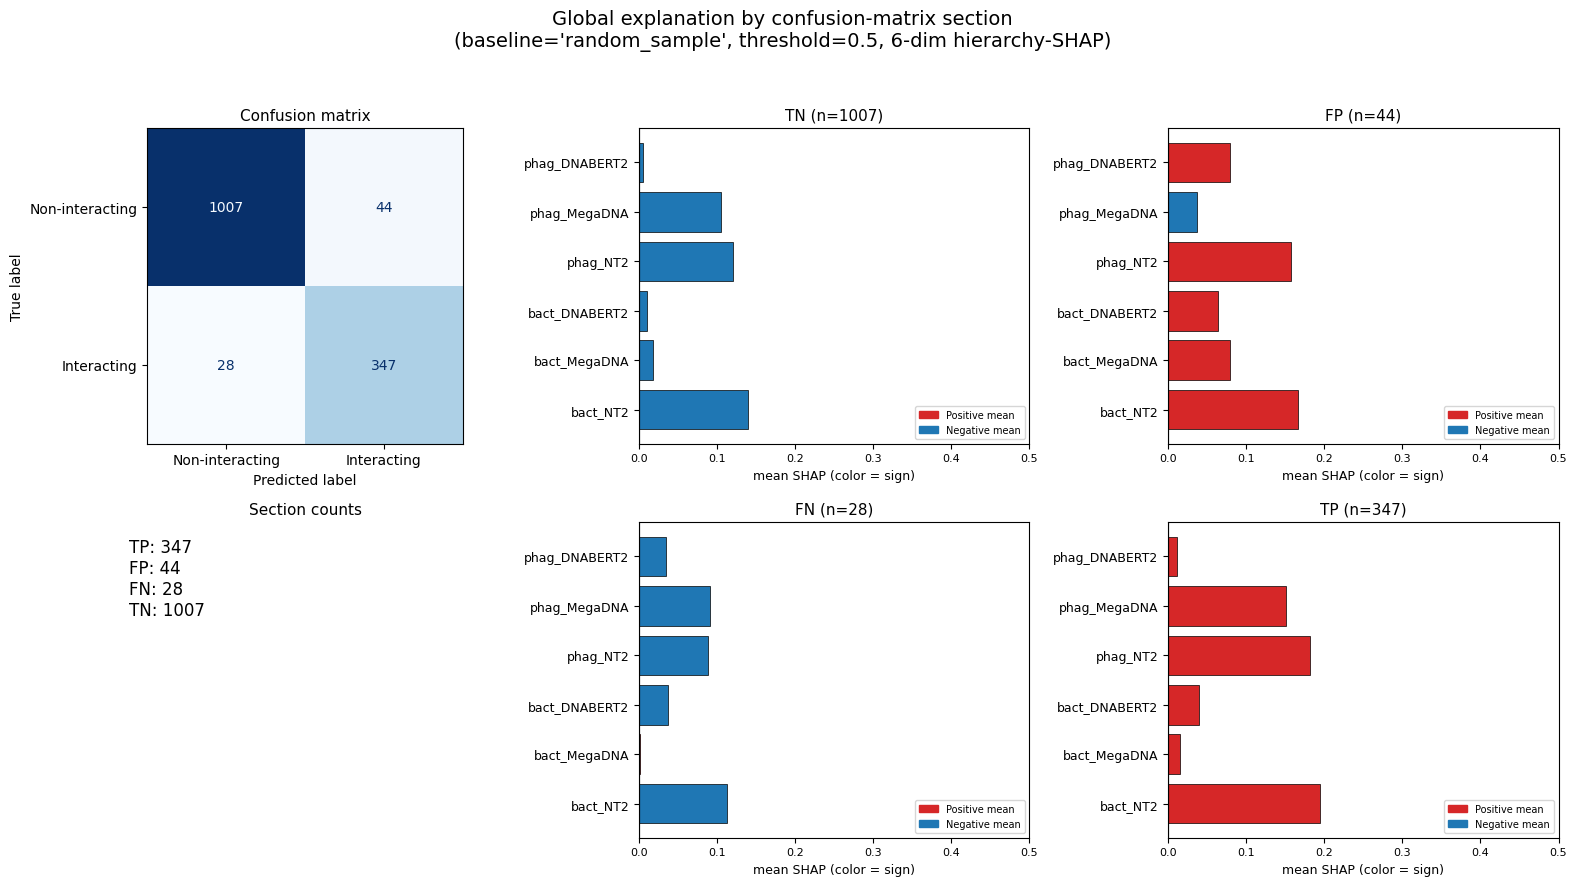

Saved combined confusion-matrix layout.


In [24]:
# ── 11c++. Confusion matrix + SHAP plots in one matrix-like layout ───────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.makedirs("XAI/results", exist_ok=True)

CLASSIF_THRESHOLD = 0.5

# Start from the global per-pair dataframe produced in Section 8
df_cm = df_global.copy()

# Predicted labels from probability threshold
df_cm["pred_label"] = (df_cm["pred_prob"] >= CLASSIF_THRESHOLD).astype(int)

def cm_section(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    elif y_true == 0 and y_pred == 0:
        return "TN"
    elif y_true == 0 and y_pred == 1:
        return "FP"
    elif y_true == 1 and y_pred == 0:
        return "FN"
    else:
        raise ValueError("Unexpected label combination.")

df_cm["cm_section"] = [
    cm_section(yt, yp) for yt, yp in zip(df_cm["true_label"], df_cm["pred_label"])
]

# Confusion matrix values
cm = confusion_matrix(
    df_cm["true_label"],
    df_cm["pred_label"],
    labels=[0, 1]
)

# Keep block/model names in alphabetical order, not SHAP order
block_order_alpha = sorted(BLOCK_NAMES)

# ---- ONE FIGURE, MULTIPLE SUBPLOTS ----
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    f"Global explanation by confusion-matrix section\n"
    f"(baseline={BASELINE_MODE!r}, threshold={CLASSIF_THRESHOLD}, 6-dim hierarchy-SHAP)",
    fontsize=14,
)

# -------------------------------------------------------------------------
# [0,0] confusion matrix
ax_cm = axes[0, 0]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-interacting", "Interacting"]
)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False, values_format="d")
ax_cm.set_title("Confusion matrix", fontsize=11)

# -------------------------------------------------------------------------
# helper to draw one SHAP chart inside a chosen axis
def plot_section_shap(ax, section_name):
    df_section = df_cm[df_cm["cm_section"] == section_name].copy()
    n_section = len(df_section)

    if n_section == 0:
        ax.text(
            0.5, 0.5,
            f"{section_name}\nno pairs",
            ha="center", va="center",
            fontsize=12,
            transform=ax.transAxes
        )
        ax.set_axis_off()
        return

    # Signed mean SHAP per block, then keep alphabetical block order
    mean_shap_section = (
        df_section[BLOCK_NAMES]
        .mean()
    )

    # Bar lengths go right using absolute magnitude
    abs_mean_vals = mean_shap_section.abs().values

    # Colors still depend on sign of the signed mean
    colors = signed_colors(mean_shap_section.values)

    ax.barh(
        mean_shap_section.index,
        abs_mean_vals,
        color=colors,
        edgecolor="k",
        linewidth=0.5,
    )

    ax.set_xlim(0, 0.5)
    ax.set_xlabel("mean SHAP (color = sign)", fontsize=9)
    ax.set_title(f"{section_name} (n={n_section})", fontsize=11)
    ax.axvline(0, color="k", linewidth=0.8)
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=8)

    pos_patch = mpatches.Patch(color=COLOR_POS, label="Positive mean")
    neg_patch = mpatches.Patch(color=COLOR_NEG, label="Negative mean")
    ax.legend(handles=[pos_patch, neg_patch], fontsize=7, loc="lower right")

# -------------------------------------------------------------------------
# Put the SHAP plots around the matrix
plot_section_shap(axes[1, 2], "TP")
plot_section_shap(axes[0, 2], "FP")
plot_section_shap(axes[1, 1], "FN")
plot_section_shap(axes[0, 1], "TN")

# Optional panel: counts summary
axes[1, 0].axis("off")
section_counts = df_cm["cm_section"].value_counts()
summary_text = "\n".join([
    f"TP: {section_counts.get('TP', 0)}",
    f"FP: {section_counts.get('FP', 0)}",
    f"FN: {section_counts.get('FN', 0)}",
    f"TN: {section_counts.get('TN', 0)}",
])
axes[1, 0].text(
    0.05, 0.95,
    summary_text,
    ha="left", va="top",
    fontsize=12,
    transform=axes[1, 0].transAxes
)
axes[1, 0].set_title("Section counts", fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(
    f"XAI/results/pictures/confusion_matrix_with_mean_hierarchy_on_{BASELINE_MODE}.png",
    dpi=150
)
plt.show()
plt.close(fig)

print("Saved combined confusion-matrix layout.")

___
## Saving The Results

In [ ]:
import os

os.makedirs("XAI/results/data", exist_ok=True)

# ── 1. Full global dump as its own file ─────────────────────────────────────
out_global_csv = f"XAI/results/data/nb2_{BASELINE_MODE}_global_on_{N_PAIRS_GLOBAL}_pairs.csv"
df_global.to_csv(out_global_csv, index=False)
print(f"Saved global dump CSV → {out_global_csv}")

# ── 2. Target ───────────────────────────────────────────────────────────────
out_target_csv = f"XAI/results/data/nb2_{BASELINE_MODE}_target.csv"
df_target.to_csv(out_target_csv, index=False)
print(f"Saved target+frozen CSV → {out_target_csv}")

Saved global dump CSV → XAI/results/data/nb2_median_global_on_20_pairs.csv
Saved target+frozen CSV → XAI/results/data/nb2_median_target.csv
